In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
csv_path  = "M2_2.18mM_pressure_o2_release.csv"
time_col  = "Time (s)"                     # your column is actually hours
press_col = "DWT denoised pressure (kPa)"  # pressure in kPa
gas_col   = "O2 Released (µmol)"          # headspace O2 from csv

In [22]:
df = pd.read_csv(csv_path)
df.columns = [c.strip() for c in df.columns]

# Plotting naq and pressure directly in multiple units (kpa and atm)

certain parts of the code must be uncomennted to plot the different graphs


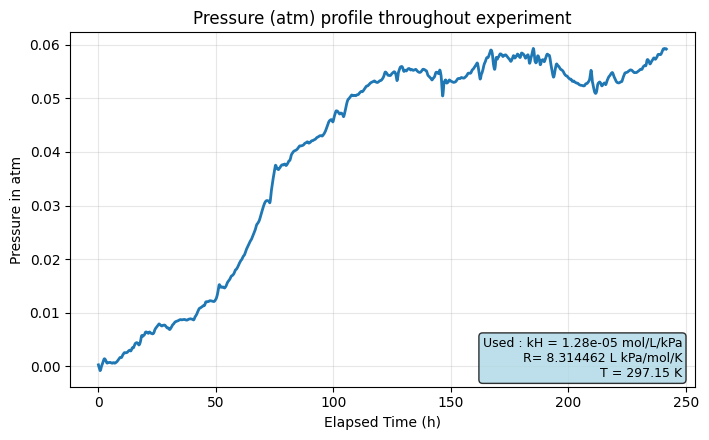

In [ ]:
time_h     = pd.to_numeric(df[time_col])
p_kpa      = pd.to_numeric(df[press_col])
n_gas_umol = pd.to_numeric(df[gas_col])


n_theory  = 13.08                         # µmol (theoretical)
kH = 1.283e-5           # mol/L/kPa
Vsol = 0.006           # L
Vg = 0.002
R = 8.314462           # L kPa/mol/K
T = 297.15             # K


def n_aq_umol_from_kpa(p_kpa: pd.Series) -> pd.Series:
    
    n_aq_umol = p_kpa * Vsol * kH * 1e6
    return n_aq_umol

def plotting_pressure(p_kpa: pd.Series) -> pd.Series:

    pressure_plot = p_kpa
    return pressure_plot

def plotting_pressure_in_atm(p_kpa: pd.Series) -> pd.Series:
    pressure_atm = p_kpa / 101.325
    return pressure_atm


#n_aq_umol = n_aq_umol_from_kpa(p_kpa)
# pressure_plot = plotting_pressure(p_kpa)
pressure_atm_plot = plotting_pressure_in_atm(p_kpa)
df_out = pd.DataFrame({
    "Elapsed Time (h)": time_h,
    # "n_aq (µmol)": n_aq_umol,
    "p_kpa (kPa)": p_kpa,
    "p_atm (atm)": pressure_atm_plot
})

plt.figure(figsize=(7.2, 4.5))



plt.plot(df_out["Elapsed Time (h)"], df_out["p_atm (atm)"], linewidth=2)
plt.ylabel("Pressure in atm")
plt.xlabel("Elapsed Time (h)")
plt.title("Pressure (atm) profile throughout experiment")





# Add detailed info box
info_text = f"""Used : kH = {kH:.2e} mol/L/kPa
R= {R} L kPa/mol/K
T = {T} K"""

plt.text(0.98, 0.02, info_text, 
         transform=plt.gca().transAxes,
         verticalalignment='bottom',
         horizontalalignment='right',
         fontsize=9,
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))



plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Using the equation directly to plot graph (in atm)
""" Units used:
K, atm, mol, L, 
KH = 1.3 x 10^-3 mol / L / atm, 
R = 0.082057 L atm / K / mol, 
T = 297.15 K





Using : Vg / (R * T) + kH * Vsol


"""

In [1]:
time_h     = pd.to_numeric(df[time_col])
p_kpa      = pd.to_numeric(df[press_col])
p_atm      = p_kpa / 101.325
n_gas_umol = pd.to_numeric(df[gas_col])

#constants
Vg = 0.002           # L
Vsol = 0.006         # L
T = 297.15  
KH = 1.3e-03
R = 0.082057



def calculate_n_total (p_atm: pd.Series, Vg: float, Vsol: float, R: float, T: float, KH: float) -> pd.Series:
    ntot = p_atm * ( (Vg / (R*T)) + (KH * Vsol)) 
    ntot_umol = ntot * 1e6  # Convert to µmol
    return ntot_umol


ntot_umol = calculate_n_total(p_atm, Vg, Vsol, R, T, KH)

print(ntot_umol.values.max())

df_out = pd.DataFrame({
    "Elapsed Time (h)": time_h,
    "n_total (µmol)": ntot_umol
})

plt.figure(figsize=(7.2, 4.5))
plt.plot(df_out["Elapsed Time (h)"], df_out["n_total (µmol)"], linewidth=2)
plt.ylabel("n_total (µmol)")
plt.xlabel("Elapsed Time (h)")
plt.title("Total oxygen (n_total) profile throughout experiment")

# Add detailed info box
info_text = f"""Used : kH = {KH:.2e} mol/L/atm
R= {R} L atm/mol/K
T = {T} K
Max o2 value in umol = {ntot_umol.values.max():.3f}"""

plt.text(0.98, 0.02, info_text, 
         transform=plt.gca().transAxes,
         verticalalignment='bottom',
         horizontalalignment='right',
         fontsize=9,
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

NameError: name 'pd' is not defined

# Same as above but instead of convertiung units to atm from kpa, keeping pressure units in Kpa

""" Units used:
K, kpa, mol, L, 
KH = 1.3 x 10^-3 mol / L / atm, 
R = 0.082057 L atm / K / mol, 
T = 297.15 K

5.325481163254313


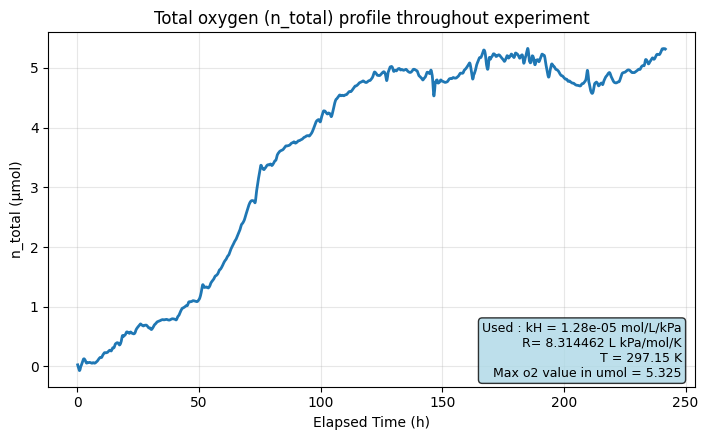

In [ ]:
time_h     = pd.to_numeric(df[time_col])
p_kpa      = pd.to_numeric(df[press_col])
n_gas_umol = pd.to_numeric(df[gas_col])

#constants
KH = 1.283e-5           # mol/L/kPa
Vsol = 0.006           # L
Vg = 0.002  
R = 8.314462           # L kPa/mol/K
T = 297.15             # K



def calculate_n_total (p_kpa: pd.Series, Vg: float, Vsol: float, R: float, T: float, KH: float) -> pd.Series:
    ntot = p_kpa * ( (Vg / (R*T)) + (KH * Vsol)) 
    ntot_umol = ntot * 1e6  # Convert to µmol
    return ntot_umol



ntot_umol = calculate_n_total(p_kpa, Vg, Vsol, R, T, KH)

print(ntot_umol.values.max())
df_out = pd.DataFrame({
    "Elapsed Time (h)": time_h,
    "n_total (µmol)": ntot_umol
})

plt.figure(figsize=(7.2, 4.5))
plt.plot(df_out["Elapsed Time (h)"], df_out["n_total (µmol)"], linewidth=2)
plt.ylabel("n_total (µmol)")
plt.xlabel("Elapsed Time (h)")
plt.title("Total oxygen (n_total) profile throughout experiment")

# Add detailed info box
info_text = f"""Used : kH = {KH:.2e} mol/L/kPa
R= {R} L kPa/mol/K
T = {T} K
Max o2 value in umol = {ntot_umol.values.max():.3f}"""

plt.text(0.98, 0.02, info_text, 
         transform=plt.gca().transAxes,
         verticalalignment='bottom',
         horizontalalignment='right',
         fontsize=9,
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))




plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Using the full equation to see if there is a difference in the total umol produced by 1. keeping pressure and other units in Kpa   and 2. Keeping pressure and other units in atm




""" Units used:

KH = 1.283e-5          
R = 8.314462  


for atm,
KH = 1.3e-3                        
R=   0.082057366080960            


Sticking with K instead of C. The ideal gas law and henry's law both scale with kelvin so using celcius scaling will become inappropriate.


Using : Vg / (R * T) + kH * Vsol


"""

In [4]:
t_h   = pd.to_numeric(df[time_col], errors="coerce")
P_kPa = pd.to_numeric(df[press_col], errors="coerce")
mask = t_h.notna() & P_kPa.notna()
t_h, P_kPa = t_h[mask].reset_index(drop=True), P_kPa[mask].reset_index(drop=True)
t_h = t_h - t_h.iloc[0]  # start time at 0 h
P_atm = P_kPa / 101.325


# Geometry & constants
Vg   = 0.002     # L
Vsol = 0.006     # L
T_K  = 297.15    # K

# --- (A) kPa-guided calculation ---
R_kPa  = 8.31446261815324              # L·kPa·mol^-1·K^-1
kH_kPa = 1.3e-3 / 101.325              # mol·L^-1·kPa^-1 (~1.283e-5)
A_kPa  = Vg/(R_kPa*T_K) + kH_kPa*Vsol  # mol/kPa
n_tot_kPa_umol = P_kPa * A_kPa * 1e6   # µmol

# --- (B) atm-guided calculation ---
R_atm  = 0.082057366080960             # L·atm·mol^-1·K^-1
kH_atm = 1.3e-3                        # mol·L^-1·atm^-1
A_atm  = Vg/(R_atm*T_K) + kH_atm*Vsol  # mol/atm
n_tot_atm_umol = P_atm * A_atm * 1e6   # µmol

# Residuals
final_kpa = max(n_tot_kPa_umol)
final_atm = max(n_tot_atm_umol)
diff_umol = final_kpa - final_atm
print(f"max values of o2 in umol produced by keeping pressure in kpa : {final_kpa}")
print(f"max values of o2 in umol produced by keeping pressure in atm : {final_atm}")
print(f"Max |difference|: {np.abs(diff_umol):.6e} µmol")

max values of o2 in umol produced by keeping pressure in kpa : 5.325480890636497
max values of o2 in umol produced by keeping pressure in atm : 5.325480890636478
Max |difference|: 1.865175e-14 µmol


The above results because of Kpa vs atm just looks like rounding noise. There is no major difference in the total umol produced by both

# Vant hoff modelling for KH


Note that this is only applicable for O2 in water for temperatures less than 348K and delta H is in KJ / mol


1. The enthalpy values of different temperatures throughout the experiment cycle is noted down in the csv file :  M2_2.18mM_pressure_o2_release_DeltaH_from_T.csv

2. This is done so by using the fitting equation given in the paper by NIRST.

In [ ]:
import pandas as pd
from pathlib import Path
import numpy as np

# ====== user inputs ======
csv_path  = "M2_2.18mM_pressure_o2_release.csv"
temp_col  = "calibrated temperature (C)"   # <-- exact column name in your file
# =========================

# Eq. (11) coefficients for O2 in water (<348 K)
A1 = 83.91236
A2 = 23.24323
R = 8.314462618  # J·mol^-1·K^-1

def deltaH_J_per_mol(T_K: pd.Series) -> pd.Series:
    """
    ΔH°(T) = R * (A2*T - 100*A1)  [J/mol]
    (Since A3 = A4 = 0 for this temperature range.)
    """
    return R * (A2 * T_K - 100.0 * A1)

# --- load & clean ---
df = pd.read_csv(csv_path)
df.columns = [c.strip() for c in df.columns]
T_C_orig = pd.to_numeric(df[temp_col], errors="coerce").dropna().reset_index(drop=True)

# --- round °C to 2 decimals, convert to K ---
T_C_round2 = T_C_orig.round(2)
T_K_from_round = T_C_round2 + 273.15

# --- compute ΔH ---
dH_Jmol  = deltaH_J_per_mol(T_K_from_round)
dH_kJmol = dH_Jmol / 1000.0

# --- assemble output table ---
out = pd.DataFrame({
    "T_C_original": T_C_orig,
    "T_C_rounded_2dp": T_C_round2,
    "T_K_from_rounded": T_K_from_round,
    "DeltaH_kJ_per_mol": dH_kJmol
})

# --- save ---
out_path = Path(csv_path).with_name(Path(csv_path).stem + "_DeltaH_from_T.csv")
out.to_csv(out_path, index=False)
print(f"Saved: {out_path}")
print(out.head(8).to_string(index=False))


Saved: M2_2.18mM_pressure_o2_release_DeltaH_from_T.csv
 T_C_original  T_C_rounded_2dp  T_K_from_rounded  DeltaH_kJ_per_mol
        24.31            24.31            297.46         -12.282996
        24.32            24.32            297.47         -12.281063
        24.31            24.31            297.46         -12.282996
        24.30            24.30            297.45         -12.284928
        24.33            24.33            297.48         -12.279130
        24.32            24.32            297.47         -12.281063
        24.31            24.31            297.46         -12.282996
        24.32            24.32            297.47         -12.281063


Now actually finding the different henry's constant values with the different H values.

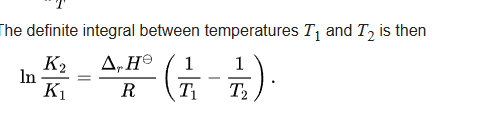

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

# ===== inputs =====
# CSV produced in the previous step (with T_K_from_rounded + DeltaH_kJ_per_mol)
dh_csv_path = "M2_2.18mM_pressure_o2_release_DeltaH_from_T.csv"
tempK_col   = "T_K_from_rounded"      # Kelvin (from rounded °C)
dH_col      = "DeltaH_kJ_per_mol"     # kJ/mol
# Reference (always relative to this):
T_REF_K     = 297.15                  # K   #change to 298.15 and see if it varies
kH_ref_atm  = 1.30e-3                 # mol·L^-1·atm^-1 at 297.15 K
R_J         = 8.314462618             # J·mol^-1·K^-1
# ==================

# Load ΔH data
df = pd.read_csv(dh_csv_path)
TK = pd.to_numeric(df[tempK_col], errors="coerce")
dH_kJmol = pd.to_numeric(df[dH_col], errors="coerce")

# van’t Hoff: kH(T) = kH_ref * exp( -(ΔH/R)*(1/T - 1/T_ref) )
dH_Jmol = dH_kJmol * 1000.0
ln_ratio = -dH_Jmol / R_J * (1.0/TK - 1.0/T_REF_K)
kH_T_atm = kH_ref_atm * np.exp(ln_ratio)   # mol·L^-1·atm^-1

# Build output table
out = pd.DataFrame({
    "Temperature_K": TK,
    "DeltaH_kJ_per_mol": dH_kJmol,
    "kH_mol_per_L_atm": kH_T_atm
})

# Save
out_path = Path("henry's constants.csv")
out.to_csv(out_path, index=False)
print(f"Saved: {out_path}")
print(out.head().to_string(index=False))




Saved: henry's constants.csv
 Temperature_K  DeltaH_kJ_per_mol  kH_mol_per_L_atm
        297.46         -12.282996          0.001293
        297.47         -12.281063          0.001293
        297.46         -12.282996          0.001293
        297.45         -12.284928          0.001293
        297.48         -12.279130          0.001293


Now using the generated Henry's constant value for each temperature on the whole equation:

Saved: M2_2.18mM_pressure_o2_release_n_total_dynamic_T_kH.csv
5.311087176954677


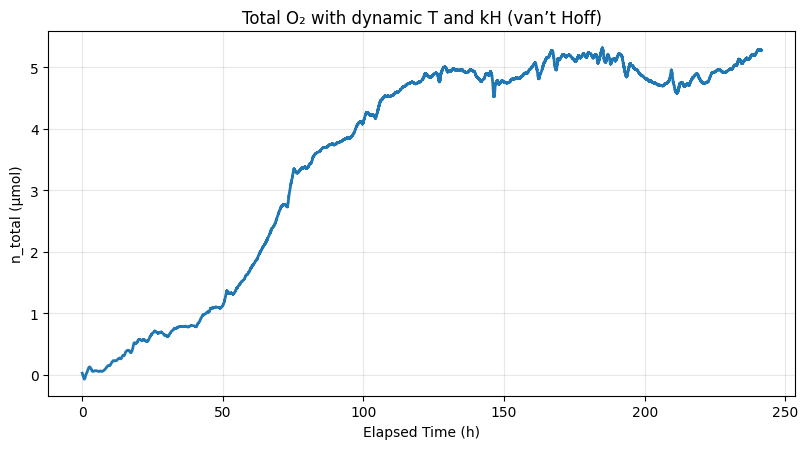

In [ ]:

henry_csv  = r"C:\Users\chand\Documents\GitHub\Thesis\henry's constants.csv"



# Constants (atm-based calc)
R   = 0.082057366079   # L·atm·mol^-1·K^-1
Vg  = 0.002            # L
Vsol= 0.006            # L


t_h   = pd.to_numeric(df[time_col])
P_kPa = pd.to_numeric(df[press_col])
mask  = t_h.notna() & P_kPa.notna()
t_h, P_kPa = t_h[mask].reset_index(drop=True), P_kPa[mask].reset_index(drop=True)
t_h = t_h - t_h.iloc[0]  # start time at 0 h



P_atm = P_kPa / 101.325

# Henry/Temperature (dynamic) from file
hdf = pd.read_csv(henry_csv)
hdf.columns = [c.strip() for c in hdf.columns]
T_K  = pd.to_numeric(hdf["Temperature_K"])
kH_T = pd.to_numeric(hdf["kH_mol_per_L_atm"])


# --- compute n_total(t) in µmol with dynamic T and kH ---
A_gas_term = Vg / (R * T_K.values)          # mol/atm
A_aq_term  = kH_T.values * Vsol             # mol/atm
A_total    = A_gas_term + A_aq_term         # mol/atm

n_tot_umol = (P_atm.values * A_total) * 1e6  # µmol

out = pd.DataFrame({
    "Elapsed Time (h)": t_h,
    "P_abs (atm)": P_atm,
    "Temperature_K": T_K,
    "kH_mol_per_L_atm": kH_T,
    "n_tot (µmol)": n_tot_umol
})
out_path = Path(csv_path).with_name(Path(csv_path).stem + "_n_total_dynamic_T_kH.csv")
out.to_csv(out_path, index=False)
print(f"Saved: {out_path}")


print(max(n_tot_umol))
# --- quick plot ---
plt.figure(figsize=(8.2, 4.6))
plt.plot(out["Elapsed Time (h)"], out["n_tot (µmol)"], linewidth=2)
plt.xlabel("Elapsed Time (h)")
plt.ylabel("n_total (µmol)")
plt.title("Total O₂ with dynamic T and kH (van’t Hoff)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Saved: M2_2.18mM_pressure_o2_release_n_total_const_vs_dynamic.csv


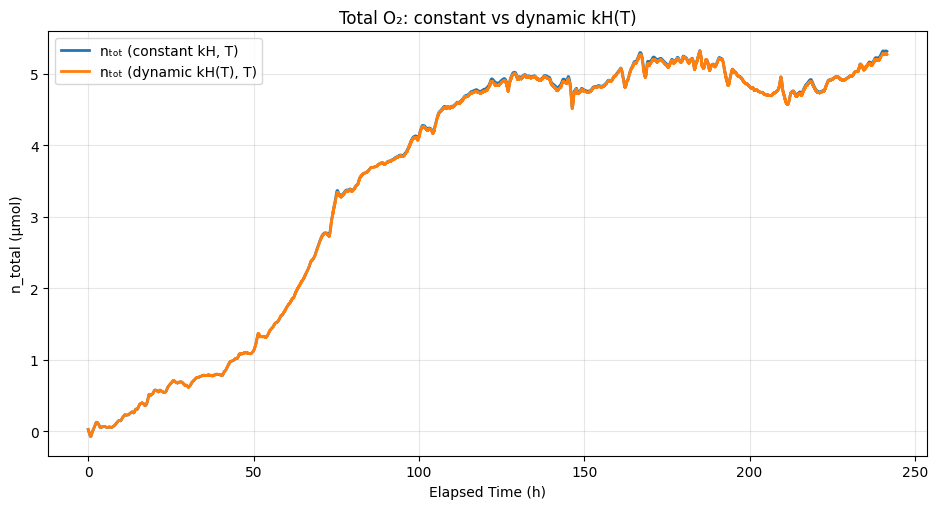

<Figure size 640x480 with 0 Axes>


=== End-of-run totals (tail median) ===
Constant: 5.319517 µmol
Dynamic : 5.276372 µmol
Δ Final : -0.043145 µmol (-0.8111 % of constant)


In [18]:

henry_csv  = "henry's constants.csv"         # must align row-wise with main_csv


# Constants (atm system)
R_atm  = 0.082057366079   # L·atm·mol^-1·K^-1
Vg     = 0.002            # L
Vsol   = 0.006            # L
KH_const = 1.3e-3         # mol·L^-1·atm^-1 (constant case)
T_const  = 297.15         # K (constant case)
KPA_PER_ATM = 101.325

# ---------- load main ----------
df = pd.read_csv(main_csv)
df.columns = [c.strip() for c in df.columns]
time_h = pd.to_numeric(df[time_col], errors="coerce")
P_kPa  = pd.to_numeric(df[press_col], errors="coerce")
mask   = time_h.notna() & P_kPa.notna()
time_h, P_kPa = time_h[mask].reset_index(drop=True), P_kPa[mask].reset_index(drop=True)
time_h = time_h - time_h.iloc[0]  # start at 0 h

# Absolute pressure (atm)

P_atm= P_kPa / KPA_PER_ATM

# ---------- load Henry (dynamic) ----------
hdf = pd.read_csv(henry_csv)
hdf.columns = [c.strip() for c in hdf.columns]
T_K_dyn  = pd.to_numeric(hdf["Temperature_K"], errors="coerce")
kH_dyn   = pd.to_numeric(hdf["kH_mol_per_L_atm"], errors="coerce")

if len(T_K_dyn) != len(P_abs_atm):
    raise ValueError(f"Row mismatch: main={len(P_abs_atm)}, henry={len(T_K_dyn)}. "
                     "Regenerate Henry file from the same filtered rows so they align 1:1.")

# ---------- n_tot (constant kH, T) ----------
A_const = Vg/(R_atm*T_const) + KH_const*Vsol   # mol/atm
n_tot_const_umol = (P_atm* A_const) * 1e6

# ---------- n_tot (dynamic kH(T), T) ----------
A_dyn = Vg/(R_atm*T_K_dyn.values) + kH_dyn.values*Vsol  # mol/atm
n_tot_dyn_umol = (P_atm.values * A_dyn) * 1e6

# ---------- differences ----------
diff_umol = n_tot_dyn_umol - n_tot_const_umol
pct_diff  = 100.0 * diff_umol / np.maximum(np.abs(n_tot_const_umol), 1e-12)

# ---------- save comparison CSV ----------
out = pd.DataFrame({
    "Elapsed Time (h)": time_h,
    "P_abs (atm)": P_atm,
    "T_K_dynamic": T_K_dyn,
    "kH_dynamic (mol/L/atm)": kH_dyn,
    "n_tot_const (µmol)": n_tot_const_umol,
    "n_tot_dynamic (µmol)": n_tot_dyn_umol,
    "diff_dynamic_minus_const (µmol)": diff_umol,
    "diff_percent_of_const (%)": pct_diff
})
out_path = Path(csv_path).with_name(Path(csv_path).stem + "_n_total_const_vs_dynamic.csv")
out.to_csv(out_path, index=False)
print(f"Saved: {out_path}")

# ---------- PLOTS ----------
# (1) Overlay with shaded difference
plt.figure(figsize=(9.5, 5.2))
plt.plot(time_h, n_tot_const_umol, linewidth=2, label="nₜₒₜ (constant kH, T)")
plt.plot(time_h, n_tot_dyn_umol, linewidth=2, label="nₜₒₜ (dynamic kH(T), T)")
# shade where dynamic > constant (above), and constant > dynamic (below)
above = n_tot_dyn_umol >= n_tot_const_umol

plt.xlabel("Elapsed Time (h)")
plt.ylabel("n_total (µmol)")
plt.title("Total O₂: constant vs dynamic kH(T)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


plt.tight_layout()
plt.show()

# (3) Optional: quick summary numbers
tail = max(5, len(time_h)//200)  # ~0.5% tail median to reduce last-point noise
final_const = float(np.median(n_tot_const_umol[-tail:]))
final_dyn   = float(np.median(n_tot_dyn_umol[-tail:]))
print("\n=== End-of-run totals (tail median) ===")
print(f"Constant: {final_const:.6f} µmol")
print(f"Dynamic : {final_dyn:.6f} µmol")
print(f"Δ Final : {final_dyn - final_const:.6f} µmol "
      f"({100*(final_dyn-final_const)/max(final_const,1e-12):.4f} % of constant)")


The dynamic correction barely moves the needle

# Using vanthoff again in KJ instead of J for enthalpy and R




In [19]:
import pandas as pd
import numpy as np
from pathlib import Path

# ==== inputs (adjust path if needed) ====
enthalpy_csv_path = "M2_2.18mM_pressure_o2_release_DeltaH_from_T.csv"
T_ref = 297.15                 # K (reference temperature)
kH_ref = 1.30e-3               # mol·L^-1·atm^-1 at T_ref
R_kJ = 0.008314462618          # kJ·mol^-1·K^-1  (so ΔH can stay in kJ/mol)
# =======================================

df = pd.read_csv(enthalpy_csv_path)

# Pull T (K) and ΔH (kJ/mol)
T_K = df["T_K_from_rounded"].astype(float)
dH_kJmol = df["DeltaH_kJ_per_mol"].astype(float)

# van’t Hoff: ln(K2/K1) = (ΔH/R) * (1/T1 - 1/T2)
# Here: K(T) = kH_ref * exp( (ΔH/R) * (1/T_ref - 1/T) )
expo = (dH_kJmol / R_kJ) * (1.0 / T_ref - 1.0 / T_K)
kH_T = kH_ref * np.exp(expo)   # mol·L^-1·atm^-1

# Build and save output
out = pd.DataFrame({
    "T_K": T_K,
    "DeltaH_kJ_per_mol": dH_kJmol,
    "kH_mol_per_L_atm": kH_T
})

out_path = Path("henry's constants_2.csv")
out.to_csv(out_path, index=False)
print(f"Saved: {out_path}")
print(out.head(8).to_string(index=False))


Saved: henry's constants_2.csv
   T_K  DeltaH_kJ_per_mol  kH_mol_per_L_atm
297.46         -12.282996          0.001293
297.47         -12.281063          0.001293
297.46         -12.282996          0.001293
297.45         -12.284928          0.001293
297.48         -12.279130          0.001293
297.47         -12.281063          0.001293
297.46         -12.282996          0.001293
297.47         -12.281063          0.001293


# use this henry's constant value with different T values to calculate ntot




Saved: M2_2.18mM_pressure_o2_release_ntot_dynamic_T_kH_in KJ.csv
5.311087201384232


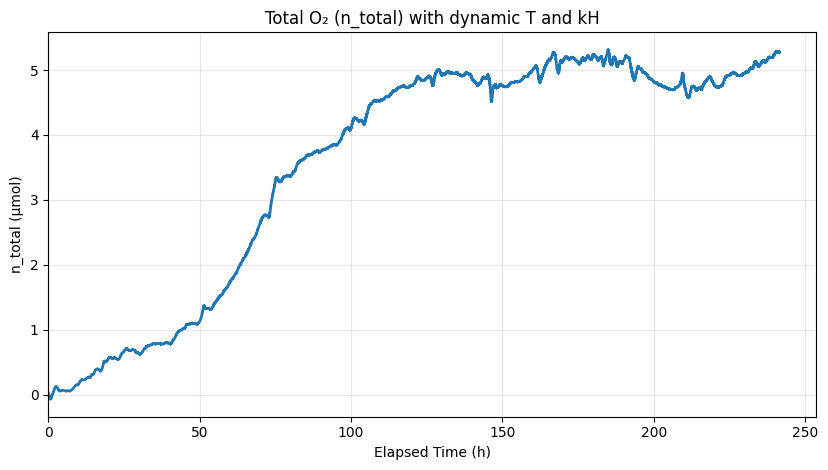

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# -------- inputs --------
main_csv_path   = "M2_2.18mM_pressure_o2_release.csv"
henry_csv_path  = "henry's constants_2.csv"   # from your previous step
time_col        = "Time (s)"                # your time column (already in hours)
press_col       = "DWT denoised pressure (kPa)"  # PO2 or total; 

# ------------------------

# Constants (atm formulation)
R = 0.08205736608096   # L·atm·mol^-1·K^-1
Vg = 0.002             # L (headspace)
Vsol = 0.006           # L (solution)
ATM_KPA = 101.325

# --- load data ---
df = pd.read_csv(main_csv_path)
df.columns = [c.strip() for c in df.columns]
hen = pd.read_csv(henry_csv_path)
hen.columns = [c.strip() for c in hen.columns]

# Pull needed series
t_h   = pd.to_numeric(df[time_col], errors="coerce")
P_kPa = pd.to_numeric(df[press_col], errors="coerce")
T_K   = pd.to_numeric(hen["T_K"], errors="coerce")
kH_T  = pd.to_numeric(hen["kH_mol_per_L_atm"], errors="coerce")

# Align lengths (assumes both files were derived row-wise from same run)
n = min(len(t_h), len(P_kPa), len(T_K), len(kH_T))
t_h   = t_h.iloc[:n].reset_index(drop=True)
P_kPa = P_kPa.iloc[:n].reset_index(drop=True)
T_K   = T_K.iloc[:n].reset_index(drop=True)
kH_T  = kH_T.iloc[:n].reset_index(drop=True)

# Absolute pressure in atm

P_abs_atm = P_kPa / ATM_KPA

# --- compute n_total(t) in µmol with dynamic T and kH ---
A_gas_term = Vg / (R * T_K.values)     # mol/atm
A_aq_term  = kH_T.values * Vsol        # mol/atm
A_total    = A_gas_term + A_aq_term    # mol/atm

n_tot_umol = P_abs_atm.values * A_total * 1e6  # µmol

# --- save results ---
out = pd.DataFrame({
    "Elapsed Time (h)": t_h - t_h.iloc[0],
    "T_K": T_K,
    "kH_mol_per_L_atm": kH_T,
    "A_gas_term (mol/atm)": A_gas_term,
    "A_aq_term (mol/atm)": A_aq_term,
    "n_total (µmol)": n_tot_umol
})
out_path = Path(main_csv_path).with_name(Path(main_csv_path).stem + "_ntot_dynamic_T_kH_in KJ.csv")
out.to_csv(out_path, index=False)
print(f"Saved: {out_path}")
print(max(n_tot_umol))
# --- quick plot ---
plt.figure(figsize=(8.4, 4.8))
plt.plot(out["Elapsed Time (h)"], out["n_total (µmol)"], linewidth=2)
plt.xlabel("Elapsed Time (h)")
plt.ylabel("n_total (µmol)")
plt.title("Total O₂ (n_total) with dynamic T and kH")
plt.grid(True, alpha=0.3)
plt.xlim(left=0)
plt.tight_layout()
plt.show()



### KK modelling for KH


take Henry's constant at 1 atm, 25°C H0 = 769
Because the K–K function is written for the “volatility” form of Henry’s constant,(the first one in the table)(source wikipedia: https://en.wikipedia.org/wiki/Henry's_law)

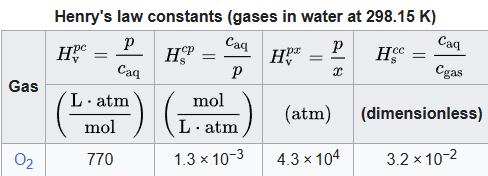

In [5]:




import pandas as pd
import numpy as np
from pathlib import Path

# -------- inputs --------
main_csv_path  = "M2_2.18mM_pressure_o2_release.csv"
henry_csv_path = "henry's constants_2.csv"     # must contain a column 'T_K'
press_col      = "DWT denoised pressure (kPa)" # PO2 in kPa (absolute)
time_col       = "Time (s)"                    # already in hours in your file
# -----------------------

# --- load data ---
df  = pd.read_csv(main_csv_path)
hen = pd.read_csv(henry_csv_path)

# --- prepare series (align lengths if needed) ---
p_kpa = pd.to_numeric(df[press_col], errors="coerce")
p_atm = p_kpa / 101.325
T_K   = pd.to_numeric(hen["T_K"], errors="coerce")

n = min(len(p_atm), len(T_K))
p_atm = p_atm.iloc[:n].reset_index(drop=True)
T_K   = T_K.iloc[:n].reset_index(drop=True)



# --- Krichevsky–Kasarnovsky (keep logic EXACTLY as provided) ---
def henry_krichevsky_kasarnovsky(P_atm, T_kelvin):
    # Reference Henry's constant at 1 atm, 25°C
    H0 = 770  # atm·L/mol

    # Partial molar volume of O2 in water at infinite dilution
    #V_infinity = 32e-6  # m3/mol (literature value for O2 in water)
    V_infinity = 32e-3  # L/mol

    # Gas constant
    #R = 8.31446261815324 	#J⋅K−1⋅mol−1
    R = 0.08206  # L·atm/(mol·K)
    P0_atm = 1.0  # Reference pressure

    # # Convert pressures to Pa
    # P_pa = P_atm * 101325
    # P0_pa = P0_atm * 101325

    # Krichevsky-Kasarnovsky equation
    ln_H = np.log(H0) + (V_infinity * (P_atm - P0_atm)) / (R * T_kelvin)
    H = np.exp(ln_H)

    return H

# --- compute H for each row ---
H_atmL_per_mol = henry_krichevsky_kasarnovsky(p_atm, T_K)

# --- save to CSV ---
out = pd.DataFrame({                # will be NaN if time_col not present
    "P_atm": p_atm,
    "T_K": T_K,
    "H_atmL_per_mol": H_atmL_per_mol
})
out_path = Path("KK_Hvalues.csv")
out.to_csv(out_path, index=False)
print(f"Saved: {out_path}")
print(out.head().to_string(index=False))


Saved: KK_Hvalues.csv
   P_atm    T_K  H_atmL_per_mol
0.000295 297.46      768.991519
0.000295 297.47      768.991552
0.000294 297.46      768.991518
0.000293 297.45      768.991483
0.000293 297.48      768.991584


Saved: ntot_from_KK_H.csv
5.315783649049959


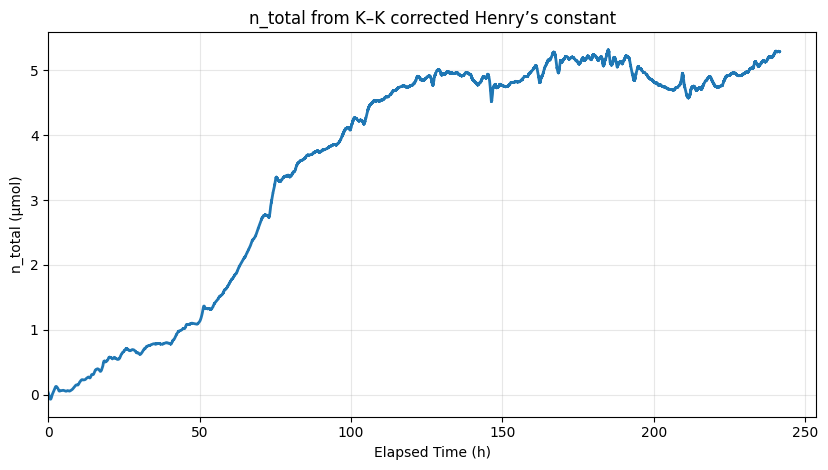

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# -------- inputs --------
main_csv_path  = "M2_2.18mM_pressure_o2_release.csv"
press_col      = "DWT denoised pressure (kPa)"   # absolute kPa for the gas you care about
time_col       = "Time (s)"                      # already hours
KK_H_csv       = "KK_Hvalues.csv"                # has columns: P_atm, T_K, H_atmL_per_mol

# ------------------------

# constants (atm, L, mol, K system)
R   = 0.08205736608096     # L·atm·mol^-1·K^-1
Vg  = 0.002                # L
Vsol= 0.006                # L


# --- load data ---
df_main = pd.read_csv(main_csv_path)
df_main.columns = [c.strip() for c in df_main.columns]
df_H    = pd.read_csv(KK_H_csv)
df_H.columns = [c.strip() for c in df_H.columns]

# pull series and align
t_h   = pd.to_numeric(df_main[time_col], errors="coerce")
P_atm = pd.to_numeric(df_H["P_atm"], errors="coerce")
T_K   = pd.to_numeric(df_H["T_K"], errors="coerce")
H     = pd.to_numeric(df_H["H_atmL_per_mol"], errors="coerce")   # atm·L/mol from K–K

n = min(len(P_atm), len(T_K), len(H))
t_h, P_atm,T_K, H = [s.iloc[:n].reset_index(drop=True) for s in (t_h, P_atm, T_K, H)]
t_h = t_h - t_h.iloc[0]  # start at 0 h

# # absolute pressure (atm)

# P_abs_atm = P_kPa / ATM_KPA

# convert H -> kH
kH = 1.0 / H  # mol·L^-1·atm^-1

# --- n_total(t) in µmol with dynamic T and kH(H from K–K) ---
A_gas_term = Vg / (R * T_K.values)   # mol/atm
A_aq_term  = kH.values * Vsol        # mol/atm
A_total    = A_gas_term + A_aq_term  # mol/atm
n_tot_umol = (P_atm.values * A_total) * 1e6

# save
out = pd.DataFrame({
    "Elapsed Time (h)": t_h,
    "P_abs (atm)": P_atm,
    "T_K": T_K,
    "H_atmL_per_mol": H,
    "kH_mol_per_L_atm": kH,
    "n_total (µmol)": n_tot_umol
})
out_path = Path("ntot_from_KK_H.csv")
out.to_csv(out_path, index=False)
print(f"Saved: {out_path}")
print(max(n_tot_umol))

# plot
plt.figure(figsize=(8.4, 4.8))
plt.plot(out["Elapsed Time (h)"], out["n_total (µmol)"], lw=2)
plt.xlabel("Elapsed Time (h)")
plt.ylabel("n_total (µmol)")
plt.title("n_total from K–K corrected Henry’s constant")
plt.grid(True, alpha=0.3)
plt.xlim(left=0)
plt.tight_layout()
plt.show()


C:\Users\chand\AppData\Local\Temp\ipykernel_9892\3771317066.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("viridis")


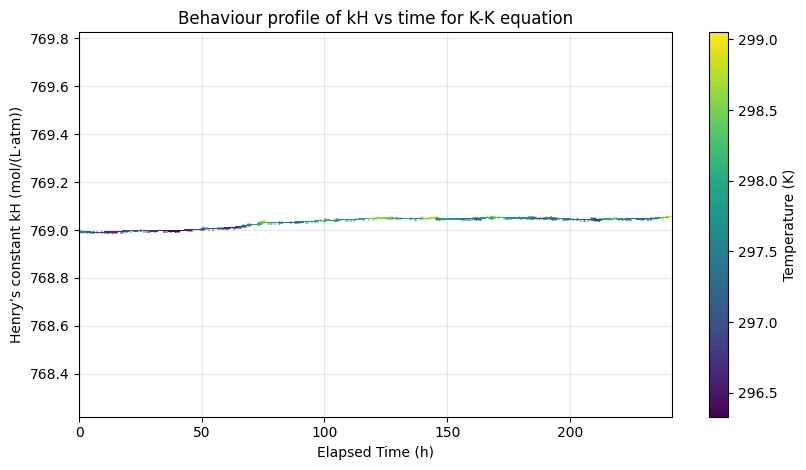

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
import matplotlib.cm as cm

# -------- inputs --------
main_csv_path  = "M2_2.18mM_pressure_o2_release.csv"
time_col       = "Time (s)"   # elapsed time column
KK_H_csv       = "KK_Hvalues.csv"  # contains P_atm, T_K, H_atmL_per_mol

# --- load data ---
df_main = pd.read_csv(main_csv_path)
df_main.columns = [c.strip() for c in df_main.columns]

df_H = pd.read_csv(KK_H_csv)
df_H.columns = [c.strip() for c in df_H.columns]

# pull series and align
t_h   = pd.to_numeric(df_main[time_col], errors="coerce")
T_K   = pd.to_numeric(df_H["T_K"], errors="coerce")
H     = pd.to_numeric(df_H["H_atmL_per_mol"], errors="coerce")

n = min(len(T_K), len(H), len(t_h))
t_h, T_K, H = [s.iloc[:n].reset_index(drop=True) for s in (t_h, T_K, H)]
t_h = t_h - t_h.iloc[0]  # start time at 0 h

# convert H -> kH
kH = 1.0 / H  # mol·L^-1·atm^-1

# --- build colored line for kH vs time ---
points = np.array([t_h, kH]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

norm = Normalize(vmin=T_K.min(), vmax=T_K.max())
cmap = cm.get_cmap("viridis")

lc = LineCollection(segments, cmap=cmap, norm=norm)
lc.set_array(T_K[:-1])  # color line by T
lc.set_linewidth(2)

# --- plot ---
fig, ax = plt.subplots(figsize=(8.4, 4.8))
line = ax.add_collection(lc)
ax.set_xlim(t_h.min(), t_h.max())
ax.set_ylim(kH.min()*0.999, kH.max()*1.001)
ax.set_xlabel("Elapsed Time (h)")
ax.set_ylabel("Henry’s constant kH (mol/(L·atm))")
ax.set_title("Behaviour profile of kH vs time for K-K equation")

cbar = fig.colorbar(line, ax=ax)
cbar.set_label("Temperature (K)")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# 1. Behaviour profile of Henry's constant on how it changes with different temperatures (from vant hoff modelling)

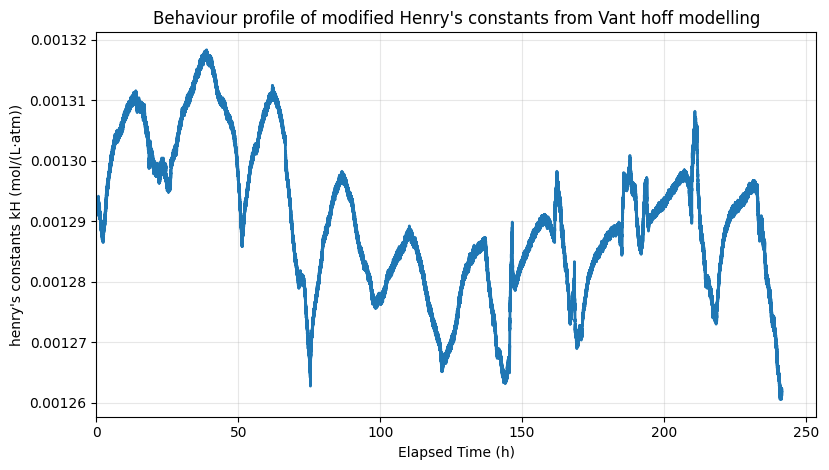

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

main_csv_path = r"C:\Users\chand\Documents\GitHub\Thesis\CSV files outputs\Vant hoff modelling fit\ntot from vanthoff fit.csv"
henry_values = "kH_mol_per_L_atm"
ntot = "n_tot"
time_col = "Elapsed Time (h)"
T_K = "Temperature_K"

df_main = pd.read_csv(main_csv_path)
df_main.columns = [c.strip() for c in df_main.columns]

t_h   = pd.to_numeric(df_main[time_col], errors="coerce")
n_tot = pd.to_numeric(df_main[ntot], errors="coerce")
k_h   = pd.to_numeric(df_main[henry_values], errors="coerce")
t_k = pd.to_numeric(df_main[T_K], errors="coerce")

n = min(len(n_tot), len(t_h), len(k_h), len(t_k))
t_h, n_tot, k_h, t_k = [s.iloc[:n].reset_index(drop=True) for s in (t_h, n_tot, k_h, t_k)]
t_h = t_h - t_h.iloc[0]  # start at 0 h


plt.figure(figsize=(8.4, 4.8))
plt.plot(t_h, k_h, lw=2)
plt.xlabel("Elapsed Time (h)")
plt.ylabel("henry's constants kH (mol/(L·atm))")
plt.title("Behaviour profile of modified Henry's constants from Vant hoff modelling")
plt.grid(True, alpha=0.3)
plt.xlim(left=0)
plt.tight_layout()
plt.show()


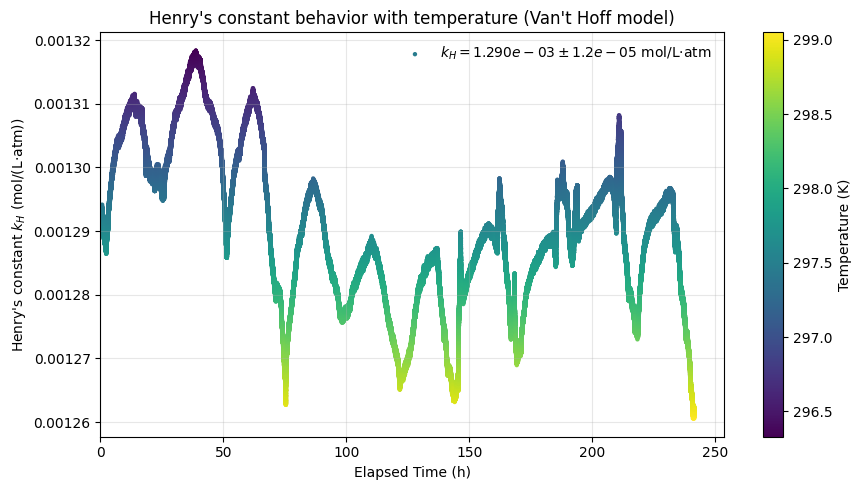

In [2]:

# Behaviour profile of KH with respect to time and temperature (Room temperature data)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

main_csv_path = r"C:\Users\chand\Documents\GitHub\Thesis\CSV files outputs -RT\Vant hoff modelling\ntot from vanthoff fit.csv"
henry_values  = "kH_mol_per_L_atm"
ntot          = "n_tot"
time_col      = "Elapsed Time (h)"
T_K           = "Temperature_K"

# Load data
df_main = pd.read_csv(main_csv_path)
df_main.columns = [c.strip() for c in df_main.columns]

# Parse columns
t_h   = pd.to_numeric(df_main[time_col], errors="coerce")
n_tot = pd.to_numeric(df_main[ntot], errors="coerce")
k_h   = pd.to_numeric(df_main[henry_values], errors="coerce")
t_k   = pd.to_numeric(df_main[T_K], errors="coerce")

# Ensure same length
n = min(len(n_tot), len(t_h), len(k_h), len(t_k))
t_h, n_tot, k_h, t_k = [s.iloc[:n].reset_index(drop=True) for s in (t_h, n_tot, k_h, t_k)]
t_h = t_h - t_h.iloc[0]  # start at 0 h

# --- stats for legend ---
k_mean = np.nanmean(k_h)
k_std  = np.nanstd(k_h)
# format in ± notation, scientific with sensible sig figs
label_stats = fr"$k_H = {k_mean:.3e} \pm {k_std:.1e}$ mol/L·atm"

# Plot kH over time, color-coded by temperature
plt.figure(figsize=(9, 5))
sc = plt.scatter(t_h, k_h, c=t_k, cmap='viridis', s=10, edgecolors='none', label=label_stats)
cbar = plt.colorbar(sc)
cbar.set_label("Temperature (K)")

plt.xlabel("Elapsed Time (h)")
plt.ylabel("Henry's constant $k_H$ (mol/(L·atm))")
plt.title("Henry's constant behavior with temperature (Van't Hoff model)")
plt.grid(True, alpha=0.3)
plt.xlim(left=0)
plt.legend(loc="best", frameon=False)
plt.tight_layout()
plt.show()




 # Observation




for O₂ in water, H decreases slightly as T rise

# 2. Modified vant hoff modelling 

previously, KH1 was used as a constant reference value with respect of all of the KH2 values being found for different temperatures.

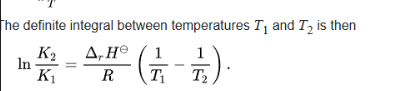

Now we model it such a way that i take rounded reference temperature.
for eg 296.8, i will take Tref as 297
for 296.4, i will take Tref as 296


In [ ]:
#first let us find the enthalpy values of  [296.0, 297.0,298.0], put it in an array
import numpy as np
T_K_array = np.array([296.0, 297.0, 298.0])
A1 = 83.91236
A2 = 23.24323
R = 8.314462618  # J·mol^-1·K^-1


for T_K in T_K_array:
    deltaH = R * (A2 * T_K - 100.0 * A1) #in J
    #in KJ
    print(f"ΔH°({T_K} K) = {deltaH / 1000:.8f} kJ/mol")
    
    
    
#find the henry's constants (k1) of these 3 values [296.0, 297.0,298.0]
import numpy as np
deltaH_KJ = np.array([-12.56514782 , -12.37189285, -12.17863789])
k1_ref = 1.30e-3 #297 is the ref for 296 and 298. for 297, 296 is the reference
ln_ratio_296 = -deltaH_KJ[0] / (8.314462618) * (1.0/296 - 1.0/297.15)
k1_296 = k1_ref * np.exp(ln_ratio_296)
print(k1_296)



ΔH°(296.0 K) = -12.56514782 kJ/mol
ΔH°(297.0 K) = -12.37189285 kJ/mol
ΔH°(298.0 K) = -12.17863789 kJ/mol


#use these henry's constants (k1) as rounded ref for all of the ref_TK in our dataset's T_K

In [ ]:
# 296.0 = 0.001300026
# 297.0 = 0.001303072
# 298.0 = 0.001281641

#hence the KH values are [0.001300026, 0.001303072, 0.001281641] for 296.0, 297.0, and 298.0 respectively.
enthalpy_csv= r"C:\Users\chand\Documents\GitHub\Thesis\CSV files outputs\Modified vant hoff modelling\Enthalpy values.csv"

import pandas as pd
import numpy as np

# Load enthalpy values (contains T_K_from_rounded and DeltaH_kJ_per_mol)

df = pd.read_csv(enthalpy_csv)
df.columns = [c.strip() for c in df.columns]

T_actual = pd.to_numeric(df["T_K_from_rounded"], errors="coerce")     # e.g., 296.4
delta_H_kJ = pd.to_numeric(df["DeltaH_kJ_per_mol"], errors="coerce")  # in kJ/mol

# Define reference kH values at 296, 297, 298 K (in mol/L/atm)
kH_reference_map = {
    296.0: 0.001300026,
    297.0: 0.001303072,
    298.0: 0.001281641,
    299.0: 0.001261560
}

# Round T to nearest int based on rule
T_ref = T_actual.apply(lambda x: np.floor(x) if x % 1 <= 0.5 else np.ceil(x))

# Get kH_ref using the rounded T
kH_ref = T_ref.map(kH_reference_map)

# Convert ΔH from kJ/mol to J/mol
delta_H_J = delta_H_kJ * 1000

# Gas constant in J/mol/K
R = 8.314462618 #using this value of R because we are dealing with joules. next we'll switch to L·atm/(K·mol) when dealing with pressure also.

# Reference Henry's constant (same as kH_ref but for formula clarity)
K1 = kH_ref
T1 = T_ref
T2 = T_actual

# Van’t Hoff: ln(K2/K1) = ΔH / R * (1/T1 - 1/T2)
ln_K2_K1 = (delta_H_J / R) * (1 / T1 - 1 / T2)
K2 = K1 * np.exp(ln_K2_K1)

# Save results
df_out = pd.DataFrame({
    "T_K_actual": T_actual,
    "T_K_ref": T_ref,
    "DeltaH_J_per_mol": delta_H_J,
    "kH_ref": K1,
    "kH_vant_hoff": K2
})
unmapped = T_ref[~T_ref.isin(kH_reference_map.keys())].unique()
if len(unmapped) > 0:
    print("⚠️ Unmapped T_ref values:", unmapped)


df_out.to_csv("modified_kH_from_vant_hoff.csv", index=False)
print("Saved: modified_kH_from_vant_hoff.csv")


if df_out["kH_vant_hoff"].isna().any():
    print("⚠️ Some kH_vant_hoff values are NaN. Check for unmapped T_ref values.")


Saved: modified_kH_from_vant_hoff.csv


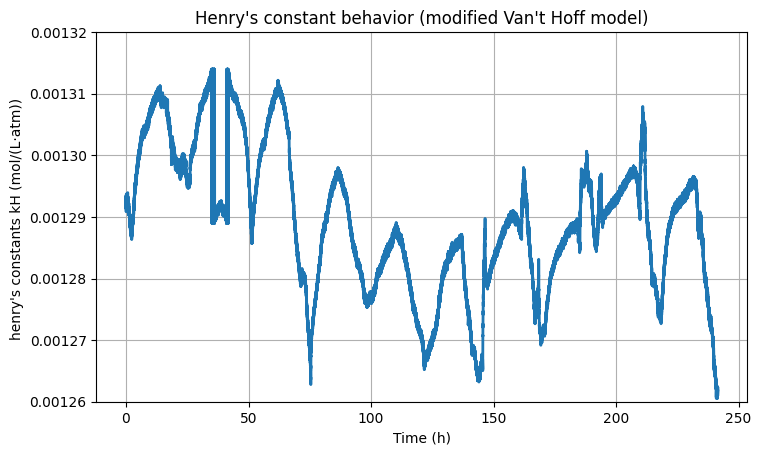

In [33]:
main_csv_path = r"C:\Users\chand\Documents\GitHub\Thesis\CSV files outputs\Modified vant hoff modelling\modified_kH_from_vant_hoff.csv"
with_time = r"C:\Users\chand\Documents\GitHub\Thesis\M2_2.18mM_pressure_o2_release_parts_and_total_umol.csv"


import pandas as pd


df = pd.read_csv(main_csv_path, encoding='latin1')  # or try 'latin1'
df.columns = [c.strip() for c in df.columns]
df_H = pd.read_csv(with_time, encoding='latin1')  # or try 'latin1'
df_H.columns = [c.strip() for c in df_H.columns]

kh_values = pd.to_numeric(df["kH_vant_hoff"], errors="coerce")     # e.g., 296.4
time = pd.to_numeric(df_H["Elapsed Time (h)"], errors="coerce")  # in seconds


#plot kh_values against time
plt.figure(figsize=(8.4, 4.8))
plt.plot(time, kh_values, lw=2)
plt.ylim(0.00126, 0.00132)  # or wider, as you wish


plt.xlabel("Time (h)")
plt.ylabel("henry's constants kH (mol/(L·atm)) ")


plt.title("Henry's constant behavior (modified Van't Hoff model)")
plt.grid()
plt.show()


# print("kH min:", kh_values.min())
# print("kH max:", kh_values.max())




C:\Users\chand\AppData\Local\Temp\ipykernel_12092\797636121.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("viridis")


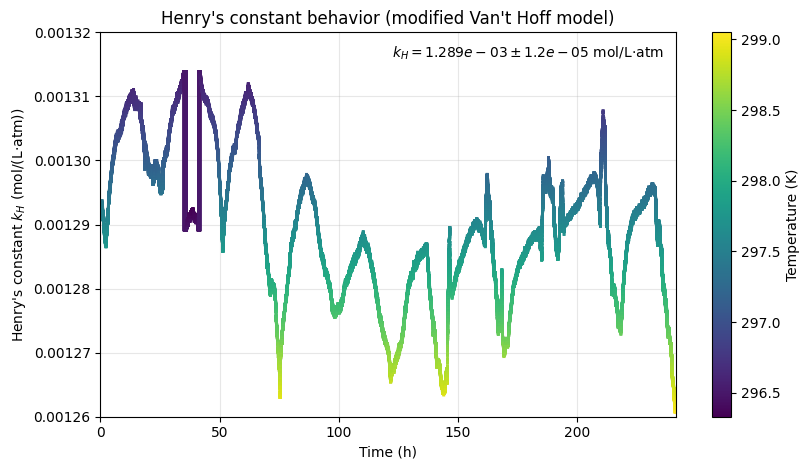

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
import matplotlib.cm as cm

# File paths
main_csv_path = r"C:\Users\chand\Documents\GitHub\Thesis\CSV files outputs -RT\Modified vant hoff modelling\modified_kH_from_vant_hoff.csv"
with_time     = r"C:\Users\chand\Documents\GitHub\Thesis\M2_2.18mM_pressure_o2_release_parts_and_total_umol.csv"

# Load data
df    = pd.read_csv(main_csv_path, encoding='latin1')
df_H  = pd.read_csv(with_time, encoding='latin1')
df.columns = [c.strip() for c in df.columns]
df_H.columns = [c.strip() for c in df_H.columns]

# Extract values
kh_values = pd.to_numeric(df["kH_vant_hoff"], errors="coerce")
time      = pd.to_numeric(df_H["Elapsed Time (h)"], errors="coerce")
T_K       = pd.to_numeric(df["T_K_actual"], errors="coerce")  # temperature for coloring

# --- Drop rows where any of these is NaN ---
mask = kh_values.notna() & time.notna() & T_K.notna()
time, kh_values, T_K = time[mask].reset_index(drop=True), kh_values[mask].reset_index(drop=True), T_K[mask].reset_index(drop=True)

# --- Stats for legend ---
k_mean = np.nanmean(kh_values)
k_std  = np.nanstd(kh_values)
label_stats = fr"$k_H = {k_mean:.3e} \pm {k_std:.1e}$ mol/L·atm"

# --- Prepare colored line segments ---
points = np.array([time, kh_values]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

norm = Normalize(vmin=T_K.min(), vmax=T_K.max())
cmap = cm.get_cmap("viridis")

lc = LineCollection(segments, cmap=cmap, norm=norm)
lc.set_array(T_K[:-1])  # temperature colors per segment
lc.set_linewidth(2)

# --- Plot ---
fig, ax = plt.subplots(figsize=(8.4, 4.8))
line = ax.add_collection(lc)
ax.set_xlim(time.min(), time.max())
ax.set_ylim(0.00126, 0.00132)
ax.set_xlabel("Time (h)")
ax.set_ylabel("Henry's constant $k_H$ (mol/(L·atm))")
ax.set_title("Henry's constant behavior (modified Van't Hoff model)")

# Add colorbar for temperature
cbar = fig.colorbar(line, ax=ax)
cbar.set_label("Temperature (K)")

# Add dummy line for legend entry with stats
ax.plot([], [], color="none", label=label_stats)
ax.legend(loc="best", frameon=False)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



reduces extrapolation distance by always starting near the current T.
Because the T band is tiny, both are essentially equivalent numerically.

# Finding ntot from the newly calculated kh

Saved: M2_2.18mM_pressure_o2_release_dynamic_T_kH_modified.csv
5.311038213092081


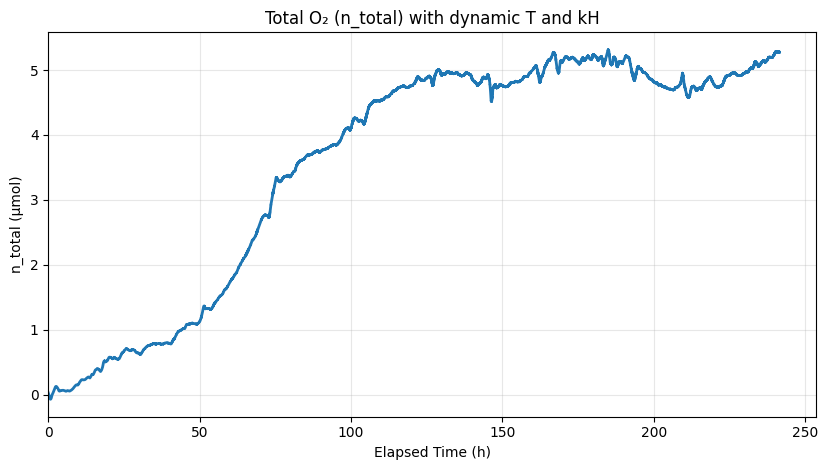

In [ ]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# -------- inputs --------
main_csv_path   = "M2_2.18mM_pressure_o2_release.csv"
henry_csv_path  = r"C:\Users\chand\Documents\GitHub\Thesis\CSV files outputs\Modified vant hoff modelling\modified_kH_from_vant_hoff.csv"
time_col        = "Time (s)"                # your time column (already in hours)
press_col       = "DWT denoised pressure (kPa)"  # PO2 or total; 

# ------------------------

# Constants (atm formulation)
R = 0.08205736608096   # L·atm·mol^-1·K^-1
Vg = 0.002             # L (headspace)
Vsol = 0.006           # L (solution)
ATM_KPA = 101.325

# --- load data ---
df = pd.read_csv(main_csv_path)
df.columns = [c.strip() for c in df.columns]
hen = pd.read_csv(henry_csv_path)
hen.columns = [c.strip() for c in hen.columns]

# Pull needed series
t_h   = pd.to_numeric(df[time_col], errors="coerce")
P_kPa = pd.to_numeric(df[press_col], errors="coerce")
T_K   = pd.to_numeric(hen["T_K_actual"], errors="coerce")
kH_T  = pd.to_numeric(hen["kH_vant_hoff"], errors="coerce")

# Align lengths (assumes both files were derived row-wise from same run)
n = min(len(t_h), len(P_kPa), len(T_K), len(kH_T))
t_h   = t_h.iloc[:n].reset_index(drop=True)
P_kPa = P_kPa.iloc[:n].reset_index(drop=True)
T_K   = T_K.iloc[:n].reset_index(drop=True)
kH_T  = kH_T.iloc[:n].reset_index(drop=True)

# Absolute pressure in atm

P_abs_atm = P_kPa / ATM_KPA

# --- compute n_total(t) in µmol with dynamic T and kH ---
A_gas_term = Vg / (R * T_K.values)     # mol/atm
A_aq_term  = kH_T.values * Vsol        # mol/atm
A_total    = A_gas_term + A_aq_term    # mol/atm

n_tot_umol = P_abs_atm.values * A_total * 1e6  # µmol

# --- save results ---
out = pd.DataFrame({
    "Elapsed Time (h)": t_h - t_h.iloc[0],
    "T_K": T_K,
    "kH_mol_per_L_atm": kH_T,
    "A_gas_term (mol/atm)": A_gas_term,
    "A_aq_term (mol/atm)": A_aq_term,
    "n_total (µmol)": n_tot_umol
})
out_path = Path(main_csv_path).with_name(Path(main_csv_path).stem + "_dynamic_T_kH_modified.csv")
out.to_csv(out_path, index=False)
print(f"Saved: {out_path}")
print(max(n_tot_umol))
# --- quick plot ---
plt.figure(figsize=(8.4, 4.8))
plt.plot(out["Elapsed Time (h)"], out["n_total (µmol)"], linewidth=2)
plt.xlabel("Elapsed Time (h)")
plt.ylabel("n_total (µmol)")
plt.title("Total O₂ (n_total) with dynamic T and kH")
plt.grid(True, alpha=0.3)
plt.xlim(left=0)
plt.tight_layout()
plt.show()



5.311087201384232 was the value without changing the T_ref and Kh_ref.
Once again no major difference in the values obtained.

# 3. Change in pressure with respect to Vg/ Vsol change


The following code will:
1. use ntot value that was previously calculated but scaled with volume ratio.
2. Uses the same concentration sample.
3. Recalculates Pressure from the already established geometry formula:

P(t)= ntot​(t)​ / ((Vg / RT) + (Kh*Vsol)), we know that this can be written as P = ntot / A


what is the min and max limit that should be allowed for Vg and Vsol?




# brute force approach to find the variables giving the highest pressure values:

In [9]:
import pandas as pd
import numpy as np

# --- data & constants (same as above) ---
csv_path = r"C:\Users\chand\Documents\GitHub\Thesis\CSV files outputs\Modified vant hoff modelling\ntot values.csv"
df = pd.read_csv(csv_path)
df.columns = [c.strip() for c in df.columns]

t_h = pd.to_numeric(df["Elapsed Time (h)"], errors="coerce")
n_tot_umol_series = pd.to_numeric(df["n_total (µmol)"], errors="coerce")
kH_series = pd.to_numeric(df["kH_mol_per_L_atm"], errors="coerce")

R = 0.08206
T_K = 297
Vsol_ref = 6.0
kH = kH_series.dropna().iloc[0] if not kH_series.dropna().empty else 1.3e-3

# --- grids ---
vsol_vals = np.arange(1.0, 10.1, 0.1)
vg_vals   = np.arange(0.5, 6.1, 0.1)

rows = []
for vsol in vsol_vals:
    volume_ratio = vsol / Vsol_ref
    n_tot_scaled_mol = (n_tot_umol_series * volume_ratio) * 1e-6
    Vsol_L = vsol / 1000

    for vg in vg_vals:
        if vsol + vg > 8.0 + 1e-9:
            continue
        Vg_L = vg / 1000
        A_total = Vg_L / (R * T_K) + kH * Vsol_L
        P_pred_kPa_series = (n_tot_scaled_mol / A_total) * 101.325
        rows.append((vsol, vg, vsol / vg, volume_ratio, float(np.max(P_pred_kPa_series))))

df_results = pd.DataFrame(rows, columns=["Vsol (mL)", "Vg (mL)", "Vsol:Vg", "Volume Ratio", "Max Pressure (kPa)"])

# Best one
best = df_results.loc[df_results["Max Pressure (kPa)"].idxmax()]
print("🔝 Best feasible combo:\n", best)

# Top 30 (handy for reporting)
top30 = df_results.sort_values("Max Pressure (kPa)", ascending=False).head(30)
print("\nTop 30 feasible combos by max pressure:\n", top30.to_string(index=False))


🔝 Best feasible combo:
 Vsol (mL)              7.500000
Vg (mL)                0.500000
Vsol:Vg               15.000000
Volume Ratio           1.250000
Max Pressure (kPa)    22.263982
Name: 2155, dtype: float64

Top 30 feasible combos by max pressure:
  Vsol (mL)  Vg (mL)   Vsol:Vg  Volume Ratio  Max Pressure (kPa)
       7.5      0.5 15.000000      1.250000           22.263982
       7.4      0.5 14.800000      1.233333           22.061549
       7.3      0.5 14.600000      1.216667           21.857367
       7.2      0.5 14.400000      1.200000           21.651415
       7.1      0.5 14.200000      1.183333           21.443669
       7.0      0.5 14.000000      1.166667           21.234107
       6.9      0.5 13.800000      1.150000           21.022703
       6.8      0.5 13.600000      1.133333           20.809434
       6.7      0.5 13.400000      1.116667           20.594274
       6.6      0.5 13.200000      1.100000           20.377200
       6.5      0.5 13.000000      1.083333

# Plotting the above values on a graph

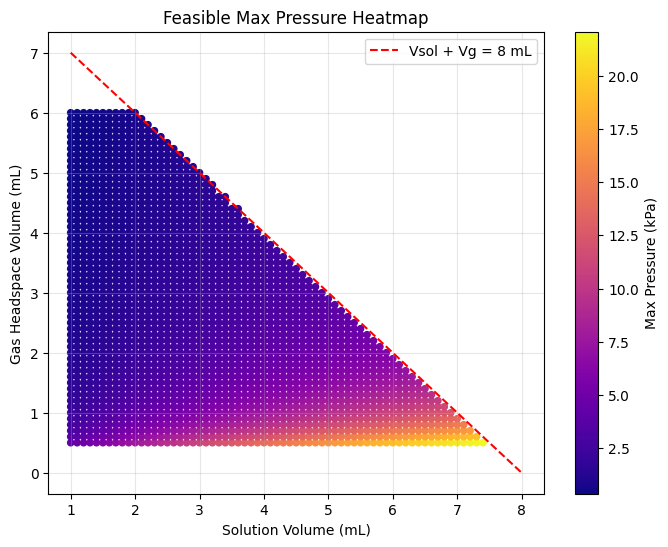

In [10]:
valid = df_results[df_results["Vsol (mL)"] + df_results["Vg (mL)"] <= 8]

plt.figure(figsize=(8,6))
sc = plt.scatter(valid["Vsol (mL)"], valid["Vg (mL)"], 
                 c=valid["Max Pressure (kPa)"], cmap="plasma", s=20)
plt.colorbar(sc, label="Max Pressure (kPa)")

# Overlay vial capacity constraint line
x = np.linspace(1, 8, 100)
plt.plot(x, 8 - x, 'r--', label="Vsol + Vg = 8 mL")

plt.xlabel("Solution Volume (mL)")
plt.ylabel("Gas Headspace Volume (mL)")
plt.title("Feasible Max Pressure Heatmap")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


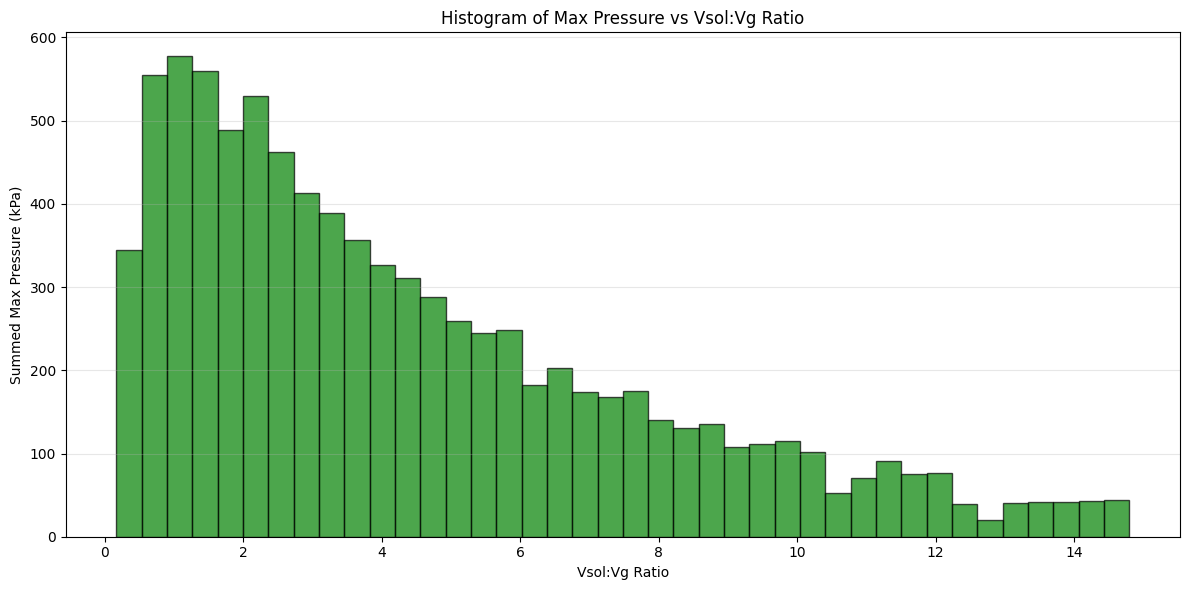

In [15]:
import matplotlib.pyplot as plt

# Filter feasible region
valid = df_results[df_results["Vsol (mL)"] + df_results["Vg (mL)"] <= 8].copy()

# Compute ratio column
valid["Vsol:Vg"] = valid["Vsol (mL)"] / valid["Vg (mL)"]

# Plot histogram-like bar chart (ratio bins on x, pressure on y)
plt.figure(figsize=(12,6))
plt.hist(valid["Vsol:Vg"], bins=40, weights=valid["Max Pressure (kPa)"],
         color="green", edgecolor="black", alpha=0.7)

plt.xlabel("Vsol:Vg Ratio")
plt.ylabel("Summed Max Pressure (kPa)")
plt.title("Histogram of Max Pressure vs Vsol:Vg Ratio")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()



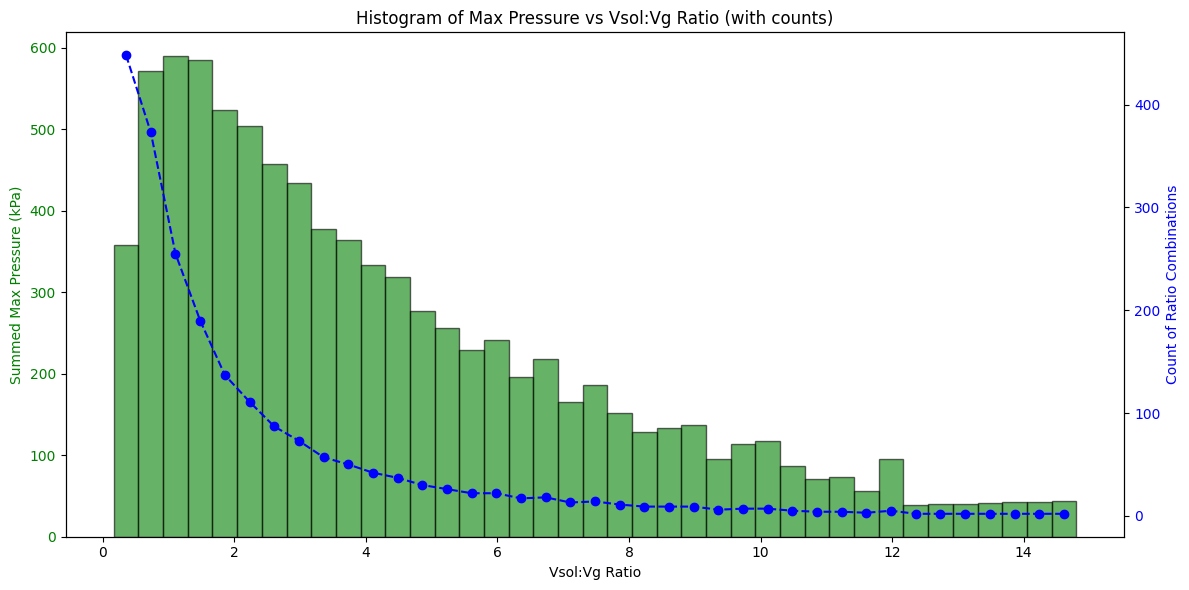

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# --- filter feasible region ---
valid = df_results[df_results["Vsol (mL)"] + df_results["Vg (mL)"] <= 8].copy()
valid["Vsol:Vg"] = valid["Vsol (mL)"] / valid["Vg (mL)"]

# --- histogram bins ---
bins = np.linspace(valid["Vsol:Vg"].min(), valid["Vsol:Vg"].max(), 40)

# --- histogram of summed pressures (what you already had) ---
pressure_sums, edges = np.histogram(valid["Vsol:Vg"], bins=bins, weights=valid["Max Pressure (kPa)"])
# --- histogram of counts (number of combinations per bin) ---
counts, _ = np.histogram(valid["Vsol:Vg"], bins=bins)

# --- compute bin centers ---
bin_centers = 0.5 * (edges[:-1] + edges[1:])

# --- plot both ---
fig, ax1 = plt.subplots(figsize=(12,6))

# Left axis = summed pressures
ax1.bar(bin_centers, pressure_sums, width=(edges[1]-edges[0]), 
        color="green", edgecolor="black", alpha=0.6, label="Summed Max Pressure (kPa)")
ax1.set_xlabel("Vsol:Vg Ratio")
ax1.set_ylabel("Summed Max Pressure (kPa)", color="green")
ax1.tick_params(axis="y", labelcolor="green")

# Right axis = counts
ax2 = ax1.twinx()
ax2.plot(bin_centers, counts, "o--", color="blue", label="Count of combinations")
ax2.set_ylabel("Count of Ratio Combinations", color="blue")
ax2.tick_params(axis="y", labelcolor="blue")

plt.title("Histogram of Max Pressure vs Vsol:Vg Ratio (with counts)")
fig.tight_layout()
plt.show()


High counts near small ratios = many (Vsol, Vg) combos possible.

Low counts at large ratios = only extreme values of Vsol and Vg create those ratios, so they are rare.

 Conclusion: 
 Although the model predicts pressures exceeding 20 kPa for extremely small headspaces (Vg < 1 mL), there is a goodchance this is not experimentally possible. I'm not sure if such high pressure can be under such a small headspace. Therefore, for a safer side, the operational range of interest is Vg ≥ 1.5–2 mL, where predicted pressures fall in the 5–15 kPa range.

 # Miscellanous past this  --- not needed
























#

Fitted k = 0.00873 1/h
Fitted n_inf = 6.257 µmol   (asymptotic total O₂)
Fitted n0 = 0.000 µmol


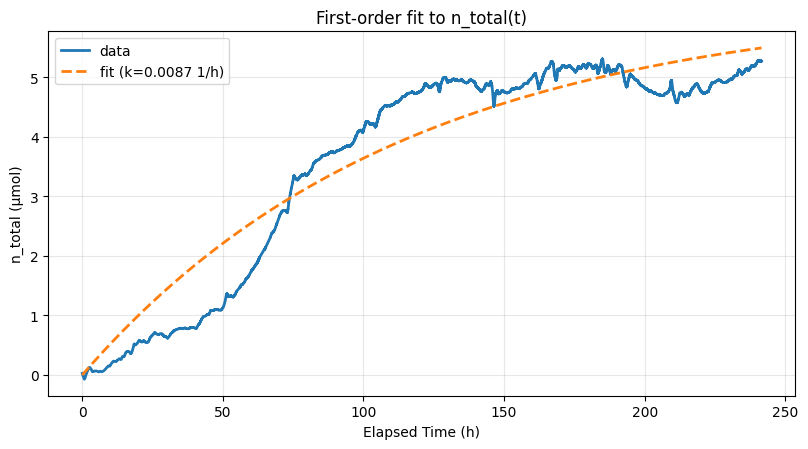

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ======= USER INPUTS =======
kinetic_csv = r"C:\Users\chand\Documents\GitHub\Thesis\CSV files outputs\Modified vant hoff modelling\ntot values.csv"
time_col_candidates = ["Elapsed Time (h)"]
ntot_col_candidates = ["n_total (µmol)"]
# ===========================

# --- load ---
df = pd.read_csv(kinetic_csv)
df.columns = [c.strip() for c in df.columns]

def pick_col(cands, cols):
    for c in cands:
        if c in cols: return c
    raise KeyError(f"Column not found. Tried: {cands}. Got: {list(cols)}")

t_col = pick_col(time_col_candidates, df.columns)
n_col = pick_col(ntot_col_candidates,  df.columns)

t_h    = pd.to_numeric(df[t_col], errors="coerce")
n_umol = pd.to_numeric(df[n_col], errors="coerce")
mask   = t_h.notna() & n_umol.notna()
t_h, n_umol = t_h[mask].reset_index(drop=True), n_umol[mask].reset_index(drop=True)
t_h = t_h - t_h.iloc[0]  # start at 0 h

# --- model: n(t) = n0 + n_inf * (1 - exp(-k t)) ---
def n_model(t, n_inf, k, n0):
    return n0 + n_inf * (1 - np.exp(-k*t))

# --- fit (SciPy if available; otherwise light grid) ---
try:
    from scipy.optimize import curve_fit
    p0 = [max(n_umol.iloc[-1], 1e-6), 0.01, max(n_umol.iloc[0], 0.0)]   # n_inf[µmol], k[1/h], n0[µmol]
    bounds = ([0.0, 0.0, 0.0], [np.inf, np.inf, np.inf])
    popt, pcov = curve_fit(n_model, t_h.values, n_umol.values, p0=p0, bounds=bounds, maxfev=20000)
    n_inf_umol, k_fit, n0_umol = popt
except Exception as e:
    print("curve_fit unavailable; doing a small grid search...", e)
    n_inf_umol = float(n_umol.iloc[-1])
    n0_umol    = float(n_umol.iloc[0])
    k_grid = np.logspace(-4, 0, 120)
    best = (np.inf, None)
    for k_try in k_grid:
        pred = n_model(t_h.values, n_inf_umol, k_try, n0_umol)
        sse  = np.sum((n_umol.values - pred)**2)
        if sse < best[0]:
            best = (sse, k_try)
    k_fit = best[1]

# fitted curve
n_fit_umol = n_model(t_h.values, n_inf_umol, k_fit, n0_umol)

print(f"Fitted k = {k_fit:.5f} 1/h")
print(f"Fitted n_inf = {n_inf_umol:.3f} µmol   (asymptotic total O₂)")
print(f"Fitted n0 = {n0_umol:.3f} µmol")

# (optional) add to df
df_fit = pd.DataFrame({"Elapsed Time (h)": t_h, "n_total (µmol)": n_umol, "n_fit (µmol)": n_fit_umol})

# quick plot
plt.figure(figsize=(8.2,4.6))
plt.plot(t_h, n_umol,  lw=2, label="data")
plt.plot(t_h, n_fit_umol, "--", lw=2, label=f"fit (k={k_fit:.4f} 1/h)")
plt.xlabel("Elapsed Time (h)"); plt.ylabel("n_total (µmol)")
plt.title("First-order fit to n_total(t)")
plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()


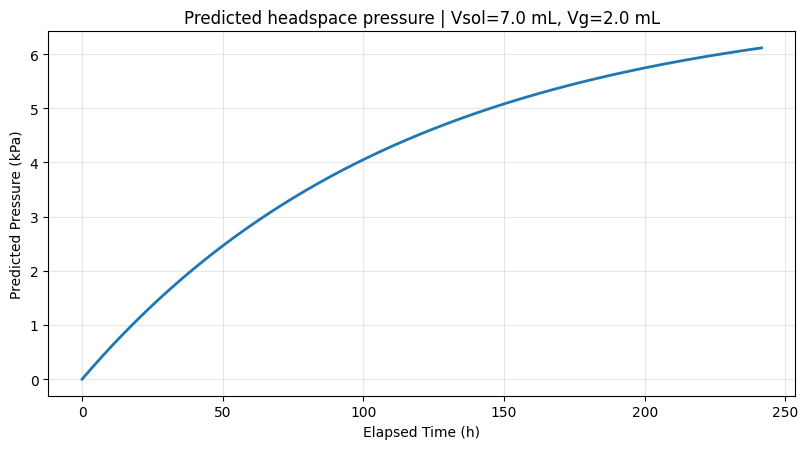

6.112662530151569
6.112662530151569
241.5144444444444


In [8]:
# ======= USER GEOMETRY / PHYSICS =======
Vsol_mL = 7.0     # change as needed
Vg_mL   = 2.0     # change as needed
T_K     = 297.15  # K
R       = 0.082057366079      # L·atm·mol^-1·K^-1
kH      = 1.3e-3              # mol·L^-1·atm^-1
k_fit = 0.00873 
n_inf_umol = 6.257
# =======================================

def predict_pressure_kPa(t_hours, n_inf_umol, k_fit, n0_umol, Vsol_mL, Vg_mL, T_K, R, kH):
    # n(t) from fitted params (convert µmol -> mol)
    n_t_mol = (n0_umol + n_inf_umol*(1 - np.exp(-k_fit*t_hours))) * 1e-6
    # geometry factor A (mol/atm)
    Vsol_L = Vsol_mL/1000.0; Vg_L = Vg_mL/1000.0
    A = Vg_L/(R*T_K) + kH*Vsol_L
    P_atm = n_t_mol / A
    return P_atm * 101.325

# compute and plot
P_kPa = predict_pressure_kPa(t_h.values, n_inf_umol, k_fit, n0_umol, Vsol_mL, Vg_mL, T_K, R, kH)

plt.figure(figsize=(8.2,4.6))
plt.plot(t_h, P_kPa, lw=2)
plt.xlabel("Elapsed Time (h)"); plt.ylabel("Predicted Pressure (kPa)")
plt.title(f"Predicted headspace pressure | Vsol={Vsol_mL:.1f} mL, Vg={Vg_mL:.1f} mL")
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

print(max(P_kPa))
print(P_kPa[-1]) #the very last value
print(t_h.values[-1]) #the time at the very last value


# Weiss henry constant fit

Not needed anymore as it is just vanthoff + salinity facrtor S, which is just 0 in our case since we use Deionised water. safe to remove.

In [ ]:
import pandas as pd
import numpy as np

def henry_constant_weiss(T_K, salinity=0):
 
    
    
    # Weiss constants for oxygen (Table 1)
    A1, A2, A3 = -58.3877, 85.8079, 23.8439
    B1, B2, B3 = -0.034892, 0.015568, -0.0019387
    
    # Calculate ln(β) using Weiss equation
    ln_beta = (A1 + A2*(100/T) + A3*np.log(T/100) + 
               salinity*(B1 + B2*(T/100) + B3*(T/100)**2))
    
    # Convert Bunsen coefficient to Henry's constant
    # β (Bunsen coefficient) relates to Henry's constant H
    beta = np.exp(ln_beta)
    
    # For Henry's law: C = H * P, where C is concentration and P is pressure
    # Bunsen coefficient β = volume of gas (STP) per unit volume of liquid at 1 atm
    # Convert to Henry's constant in mol/(L·atm)
    # At STP: 1 mol gas = 22.414 L, so β/22.414 gives mol/L at 1 atm
    henry_constant = beta / 22.414
    
    return henry_constant

# Load your CSV file
# Replace 'your_file.csv' with your actual CSV filename
df = pd.read_csv('C:\Users\chand\Documents\GitHub\Thesis\CSV files outputs\Modified vant hoff modelling\Enthalpy values.csv')

# Extract temperature column
# Replace 'Temperature' with your actual temperature column name
T_K = df['T_K_from_rounded']

# Calculate Henry's constants for each temperature
henry_constants = []
for temp in T_K :
    H = henry_constant_weiss(temp, salinity=0)  # Pure water, change salinity if needed
    henry_constants.append(H)

# Add Henry's constant column to dataframe
df['Henry_Constant_Weiss'] = henry_constants

# Also calculate for comparison at specific temperatures
temp_RT = 24  # Room temperature
temp_37 = 37  # Body temperature

H_RT = henry_constant_weiss(temp_RT)
H_37 = henry_constant_weiss(temp_37)

print(f"Henry's constant at {temp_RT}°C: {H_RT:.6f} mol/(L·atm)")
print(f"Henry's constant at {temp_37}°C: {H_37:.6f} mol/(L·atm)")
print(f"Ratio H_37/H_RT: {H_37/H_RT:.3f}")

# Save updated dataframe to new CSV
df.to_csv('data_with_henry_constants.csv', index=False)

print("\nHenry's constants calculated and saved to 'data_with_henry_constants.csv'")
print(f"Processed {len(T_K)} temperature points")

# Display first few rows to verify
print("\nFirst 5 rows of updated data:")
print(df[['Temperature', 'Henry_Constant_Weiss']].head())

# 4. Time delay analysis between absorbance and pressure
for this, i need the full absorbance dataset and not just the spectrometer dataset

# 5. Cross-modal validation:
### does optical data predict pressure behavior and vice versa?

I have a calculation to this for now. i have to cross validate it..

# Key questions to be answered post this analysis:
1. Is it possible to predict pressure from absorbance data alone
2. What is the correlation coefficient between the two sigmals over time?
3. Are there phases where one method is more reliable than the other?

# 6. Headspace + Volume effects analysis:
### (this section is already partially answered with the previous analysis just for pressure sensor)
* Henry's law validation 
* Deetection efficiency vs volume ratio (How does the system geometry affect what can be measured)
* Does pressure per umol o2 scale with geometry?

# 7. Temperature dependence modelling:
* Arrhenius relationship (I assume this has been already covered? check once with Abhishek)
* Predictive model to estimate the half life at untested temperatures (PRECISELY !)



# 8. Scaling / Conversion factors

Since the end model has to work across different concentrations (uM, mM), different geometries of volume to headspace ratios, different temperatures, different measurement types (optical or pressure),
it is critical to establish a common scaling factor.

